This notebook contains training a neural network for additional current with which we try to match the recording from a single-compartment ACTIVE model to our real, experimental data. Here, we try to only match the first spike with 300 sets of parameters (parallelly training different initializations).

Here we use the normalized voltage and the us as input to the neural network (time is not included!). We define u in a differential equation.

We initialize the NN based on https://arxiv.org/pdf/2311.15890, and with it we get stable u values.

After training, we fine-tune the best 40 models with SSE loss.

In [2]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

%load_ext autoreload
%autoreload 2


from jax import config
config.update("jax_enable_x64", True)



import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax
import jaxley as jx


import flax.nnx as nnx

Let's see our data!

In [3]:
t_max = 80.0
cut = 1500

setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"



# Define target
from voltage_fitting.build_simulator import (
    get_experimental_data,
)
t, v_data, i_amp = get_experimental_data(setup, cut, t_max)
v_data = jnp.asarray(v_data[None,])

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


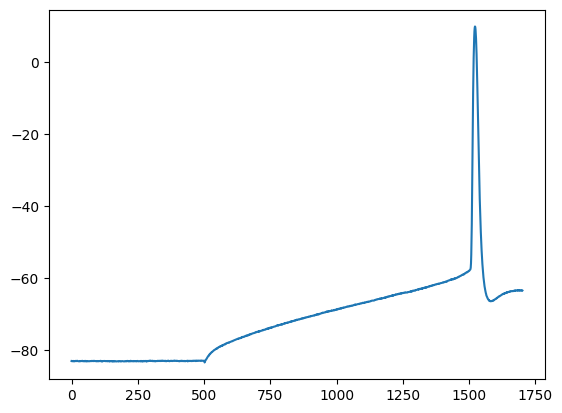

In [4]:
plt.plot(v_data[0])

In [5]:
#Define the cell
from voltage_fitting.single_build_simulator import (
    setup_simulator,
    setup_simulator_step,
    build_cell,
    set_setup,
    get_bounds,
    transform_uniform_to_normal,
    get_prior
)

seed = 0

rng_key = jax.random.PRNGKey(seed)

all_setup = set_setup(setup)
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_single = simulate_single(inv_sampled_params, v_data[0])[0]


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 15


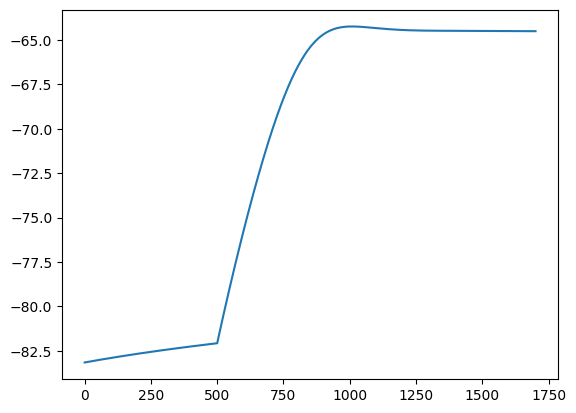

In [6]:
# Oe random simulation
plt.plot(v_single[0])

How do 100_000 random simulations look like? Are the spikes too high?

In [7]:
from voltage_fitting.loss_util import (
    get_scaled_loss,
)


n_params = 100_000
opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_params)
)

def predict(params):
    inv_params = inv_transform_params(params)
    
    simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)
    v = simulate_single(inv_params, v_data[0])[0]
    return get_scaled_loss(v_data[0], v[0], 1.0, 0.05), jnp.abs(jnp.max(v[0])-10.0)

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])
losses, diffs = jax.vmap(predict)(opt_params)


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [8]:
print('Min loss: ', np.min(losses), ', index: ', np.argmin(losses))
print('Min height diff: ', np.min(diffs), 'index: ', np.argmin(diffs))

Min loss:  16.26498944798083 , index:  4151
Min height diff:  0.0027496782037630396 index:  16035


In [9]:
print('Number of spikes: ', jnp.sum(diffs < 30))

Number of spikes:  9825


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


Text(0.5, 1.0, 'Best height')

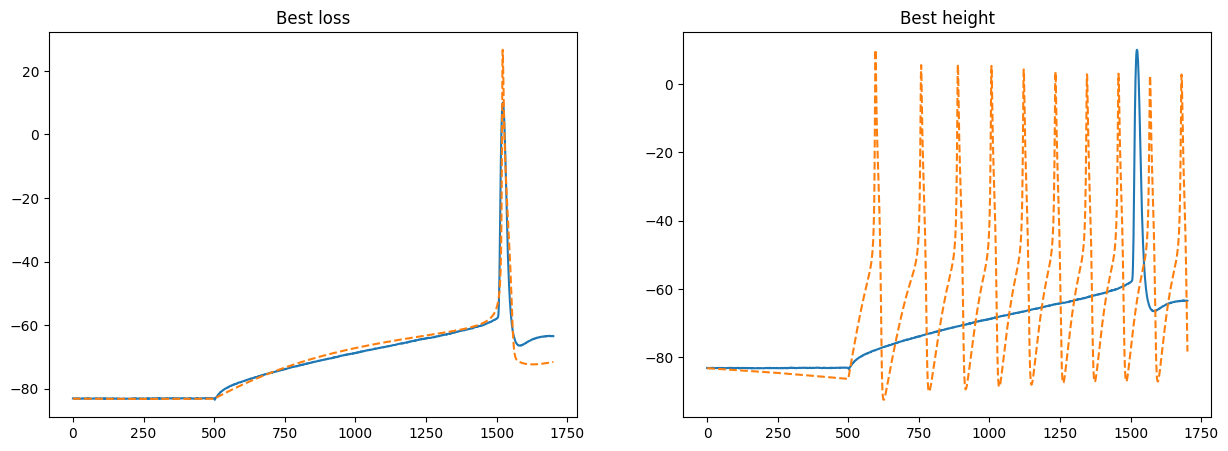

In [10]:
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])
inv_params = inv_transform_params(opt_params[np.argmin(losses)])
    
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)
v = simulate_single(inv_params, v_data[0])[0]


fig, axs = plt.subplots(1,2, figsize = (15,5))

axs[0].plot(v_data[0])
axs[0].plot(v[0], linestyle='--')
axs[0].set_title("Best loss")

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])
inv_params = inv_transform_params(opt_params[np.argmin(diffs)])
    
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)
v = simulate_single(inv_params, v_data[0])[0]

axs[1].plot(v_data[0])
axs[1].plot(v[0], linestyle='--')
axs[1].set_title("Best height")

**Initialization**

In [11]:
from voltage_fitting.initialization import (
    rejection_sample_eigenvalues,
    generate_all_lambda_matrices,
    generate_all_pi_matrices,
    generate_W_matrices

)

In [12]:
key = jax.random.PRNGKey(0)
dt = 0.025
u_dimension = 8

eigs = rejection_sample_eigenvalues(
    key = key,
    solver_order=1,   # RK4
    h=dt,
    u_dim=u_dimension,
    use_complex=True
)

print("Sampled Eigenvalues:")
for e in eigs:
    print(e, "scaled: ", dt*e)

Sampled Eigenvalues:
(-42.141613528976286-22.98417698424073j) scaled:  (-1.0535403382244073-0.5746044246060182j)
(-42.141613528976286+22.98417698424073j) scaled:  (-1.0535403382244073+0.5746044246060182j)
(-8.516035334431441+15.86861961008248j) scaled:  (-0.21290088336078605+0.396715490252062j)
(-8.516035334431441-15.86861961008248j) scaled:  (-0.21290088336078605-0.396715490252062j)
(-21.545506252691013-34.14736393037374j) scaled:  (-0.5386376563172753-0.8536840982593437j)
(-21.545506252691013+34.14736393037374j) scaled:  (-0.5386376563172753+0.8536840982593437j)
(-36.88311383073451-19.00424583475928j) scaled:  (-0.9220778457683627-0.47510614586898203j)
(-36.88311383073451+19.00424583475928j) scaled:  (-0.9220778457683627+0.47510614586898203j)


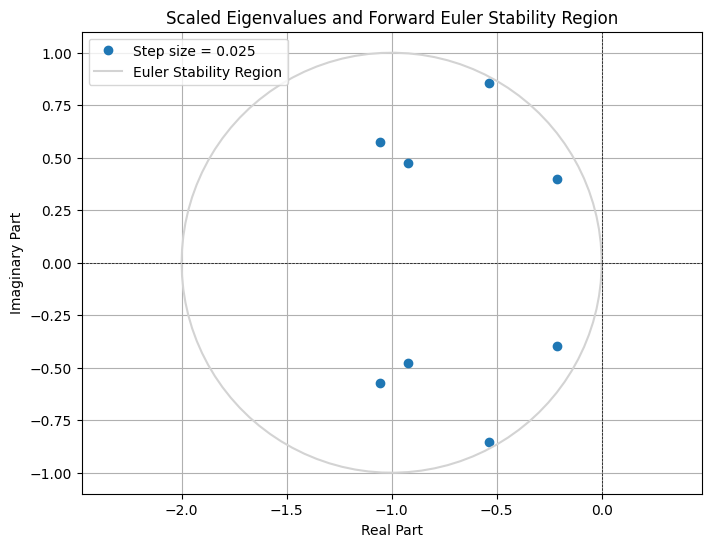

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot scaled eigenvalues for each h
scaled_eigs = dt*eigs
ax.plot(scaled_eigs.real, scaled_eigs.imag, 'o', label=f"Step size = {dt}")

# Plot Euler's method stability region: circle centered at -1 with radius 1
theta = np.linspace(-np.pi, np.pi, 100)
x = -1 + np.cos(theta)
y = np.sin(theta)
ax.plot(x, y, color='lightgrey', label='Euler Stability Region')

ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.2, 0.2)

ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title("Scaled Eigenvalues and Forward Euler Stability Region")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend()
ax.grid(True)
plt.axis('equal')
plt.show()

Now we make the Lambda, Pi and W matrices based on the paper

In [14]:
num_layers = 3
layer_shapes = [(u_dimension + 1, 32), (32, 16), (16, u_dimension)]

lambda_matrices = generate_all_lambda_matrices(layer_shapes, eigs, num_layers)

pi_matrices = generate_all_pi_matrices(key, layer_shapes)

W_matrices = generate_W_matrices(lambda_matrices, pi_matrices)

In [15]:
# Checking the eigenvalues of the generated initialization
jnp.linalg.eigvals(W_matrices[2]@W_matrices[1]@W_matrices[0][:, :u_dimension])

Array([-42.14161353+22.98417698j, -42.14161353-22.98417698j,
       -21.54550625+34.14736393j, -21.54550625-34.14736393j,
       -36.88311383+19.00424583j, -36.88311383-19.00424583j,
        -8.51603533+15.86861961j,  -8.51603533-15.86861961j],      dtype=complex128)

I had to change to eqx.Module from nnx.Module to be able to parallelize training

In [16]:
# Define the networks
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_data)) / (jnp.max(v_data) - jnp.min(v_data)) - 1

@jax.jit
def softsign_transform(v):
    return v / (1 + jnp.abs(v))

@jax.jit
def tempered_tanh(v, scale=0.05):
    return jnp.tanh(scale * v)

In [17]:
import jax
import jax.numpy as jnp
import equinox as eqx
import jax.random as jr
from typing import List

class SimpleNeuralNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear
    linear3: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2, k3, k_b1, k_b2, k_b3 = jr.split(key, 6)

        self.linear1 = eqx.nn.Linear(u_dimension + 1, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 16, key=k2)
        self.linear3 = eqx.nn.Linear(16, u_dimension, key=k3)

        # Stability-informed initialization
        self.linear1 = eqx.tree_at(lambda l: l.weight, self.linear1, W_matrices[0])
        self.linear2 = eqx.tree_at(lambda l: l.weight, self.linear2, W_matrices[1])
        self.linear3 = eqx.tree_at(lambda l: l.weight, self.linear3, W_matrices[2])

        self.linear1 = eqx.tree_at(
            lambda l: l.bias, self.linear1,
            jr.uniform(k_b1, (32,), minval=-epsilon, maxval=epsilon)
        )
        self.linear2 = eqx.tree_at(
            lambda l: l.bias, self.linear2,
            jr.uniform(k_b2, (16,), minval=-epsilon, maxval=epsilon)
        )
        self.linear3 = eqx.tree_at(
            lambda l: l.bias, self.linear3,
            jr.uniform(k_b3, (u_dimension,), minval=-epsilon, maxval=epsilon)
        )

    def __call__(self, x):
        x = jax.nn.relu(self.linear1(x))
        x = jax.nn.relu(self.linear2(x))
        return self.linear3(x)


class ReadoutNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8):
        k1, k2 = jr.split(key, 2)
        self.linear1 = eqx.nn.Linear(u_dimension, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 1, key=k2)

    def __call__(self, u):
        x = jax.nn.relu(self.linear1(u))
        return self.linear2(x)


class CorrectionModel(eqx.Module):
    neural_net: SimpleNeuralNet
    readout_net: ReadoutNet
    channel_params_normal: jax.Array

    def __init__(self, *, key, init_params, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2 = jr.split(key, 2)
        self.neural_net = SimpleNeuralNet(key=k1, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.readout_net = ReadoutNet(key=k2, u_dimension=u_dimension)
        self.channel_params_normal = init_params

    def __call__(self, u, v):
        u_new = self.neural_net(u, v)
        return self.readout_net(u_new)

In [18]:
dt = 0.025
max_add_current = 1.0

def simulate_full_trace(neural_net, readout_net, initial_state, step_fn, current, time_vec, u_init, x_o, added_curr_std, u_time_constant, thr = None):
    def cond_fn(carry):
        t, _, _, _, diff = carry
        keep_running = t < len(time_vec)
    
        if thr is None:
            return keep_running
        else:
            return jnp.logical_and(keep_running, diff < thr)

    def body_fn(carry):
        t, state, u, recs_adds, diff = carry

        rec_inds = cell.recordings.rec_index.to_numpy()

        #voltage = state["v"][rec_inds].squeeze()
        voltage = state["v"].squeeze()
        voltage_normalized = normalize_voltage(voltage)
        #voltage_normalized = softsign_transform(voltage)
        #voltage_normalized = tempered_tanh(voltage)
        inputs = jnp.concatenate([u, jnp.expand_dims(voltage_normalized, 0)], axis=0)

        u_new = u + dt*neural_net(inputs) / u_time_constant #0.02 #0.0008
        add_current = readout_net(u_new).squeeze()

        nn_res = neural_net(inputs)


        total_current = current[t] + add_current * added_curr_std #/300 #10
        state, rec = step_fn(state, total_current)

        rec_voltage = rec[0]

        new_us, new_recs, new_adds, nn_reses = recs_adds
        new_recs = new_recs.at[t].set(rec_voltage)
        new_adds = new_adds.at[t].set(add_current)
        new_us = new_us.at[t].set(u_new)
        nn_reses = nn_reses.at[t].set(nn_res)

        new_diff = diff + (rec_voltage - x_o[t + 1])**2

        return (t + 1, state, u_new.squeeze(), (new_us, new_recs, new_adds, nn_reses), new_diff)

    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)
    adds = jnp.full((len(time_vec),), jnp.nan)
    us = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)
    nn_reses = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)

    carry = (0, initial_state, u_init.squeeze(), (us, recs, adds, nn_reses), 0.0)

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    _, _, _, (us, recs, adds, nn_reses), _ = final_carry

    return recs, adds, us, nn_reses

In [19]:
cost_fn_power = 1.0
scale = 0.05

def loss_fn(model, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, u_time_constant, thr=300, spike_reg = 2.0, sse_reg = 0.0, add_reg = 0.0):

    params = inv_transform_params(model.channel_params_normal)

    # Rebuild the simulator with new cell
    initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = params)

    # Run simulation
    preds, additional_currents, us, nn_reses = simulate_full_trace(
        model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
    )

    preds = preds.squeeze()
    v_data = v_data.squeeze()

    sse_loss = jnp.sum(jnp.nan_to_num((preds - v_data) ** 2, nan=0.0))
    add_loss = jnp.sum(jnp.abs(jnp.nan_to_num(additional_currents, nan=0.0)))

    scaled_loss = get_scaled_loss(v_data, preds, cost_fn_power, scale)

    spike_loss = jnp.abs(jnp.max(preds) - jnp.max(v_data))
    
    return scaled_loss + sse_loss * sse_reg + spike_loss * spike_reg + add_loss * add_reg

With changing the learning rate, the scheduler, the gradient normalization it could be optimized better. It was optimized for stricter parameter bounds, but I changed back to the original ones.

In [ ]:
u_dimension = 8
np.random.seed(42)
n_particles = 300

rngs = nnx.Rngs(1)
key = jax.random.PRNGKey(0)
keys = jax.random.split(jax.random.PRNGKey(0), num=n_particles)

u_init = jnp.asarray(np.random.randn(u_dimension))  # Initial hidden state of the neural network
epsilon = 1e-4

all_setup = set_setup(setup)


log_uniform_samples = jax.random.uniform(key, shape=(u_dimension,), minval=np.log(0.1), maxval=np.log(10.0))
u_time_constant = jnp.exp(log_uniform_samples)
added_curr_std = 1.0/10.0 #1/50


thr = None


initial_lr = 15e-4 #2e-1 for lbfgs?
decay_factor = 1 #0.99
transition_steps = 1  # decay after every epoch
#decay_until = 400 after x epochs, stop decaying
decay_start = 1
decay_end = 350


opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_particles)
)


def initialize_model(key, init_params, u_dimension, W_matrices, epsilon):
    model = CorrectionModel(
        key=key,
        init_params=init_params,
        u_dimension=u_dimension,
        W_matrices=W_matrices,
        epsilon=epsilon
    )
    return model


models = jax.vmap(initialize_model, in_axes=(0, 0, None, None, None))(
    keys, opt_params, u_dimension, W_matrices, epsilon
)

raw_schedule = optax.exponential_decay(
    init_value=initial_lr,
    transition_steps=transition_steps,
    decay_rate=decay_factor,
    staircase=True,
)


def custom_schedule(step):
    # Epochs before decay_start → constant
    lr = initial_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        initial_lr,
        raw_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = raw_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr


adam_optimizer = optax.adam(learning_rate=custom_schedule)
lbfgs_optimizer = optax.chain(
            optax.scale_by_lbfgs(memory_size = 6), #8
            optax.scale(-1e-3), #0.3
        )
adamw_optimizer = optax.adamw(
    learning_rate=custom_schedule, 
    weight_decay=1e-4              
)

def init_adam_optimizer_state(model):
    return adam_optimizer.init(eqx.filter(model, eqx.is_inexact_array))

def init_lbfgs_optimizer_state(model):
    return lbfgs_optimizer.init(eqx.filter(model, eqx.is_inexact_array)) 

def init_adamw_optimizer_state(model):
    return adamw_optimizer.init(eqx.filter(model, eqx.is_inexact_array))


optimizer_states = jax.vmap(init_adam_optimizer_state)(models)
# optimizer_states = jax.vmap(init_adam_optimizer_state)(models)
# optimizer_states = jax.vmap(init_lbfgs_optimizer_state)(models)

# I added a little weight on the difference between the max of the prediction and the max of the data to better match the spike heights
def simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, u_time_constant, thr, spike_reg = 2.0, sse_reg = 0.0, add_reg = 0.0)
        return loss

def fine_simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, u_time_constant, thr, spike_reg = 0.0, sse_reg = 1.0, add_reg = 0.0)
        return loss


grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(simulation_loss_fn)))
fine_grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(fine_simulation_loss_fn)))

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current, verbose = False)
cell.record(verbose = False)
# cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
# cell.soma.branch(0).comp(0).record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

In [26]:
def clip_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling
    return jax.tree_util.tree_map(clip_leaf, grads)

def clip_channel_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    clipped = clip_leaf(grads.channel_params_normal)
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, clipped)
    return grads

def clip_network_gradients(grads, max_norm=1.0, eps=1e-8):
    def clip_leaf(grad):
        if grad.ndim < 2:
            return grad  # Skip biases or scalars
        flat = grad.reshape((grad.shape[0], -1))
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    def clip_net(net_grads):
        return jax.tree_util.tree_map(clip_leaf, net_grads)

    grads = eqx.tree_at(lambda g: g.neural_net, grads, clip_net(grads.neural_net))
    grads = eqx.tree_at(lambda g: g.readout_net, grads, clip_net(grads.readout_net))

    return grads

def normalize_gradients(grads, beta=1.0, eps=1e-8):
    def normalize_leaf(grad):
        norm = jnp.linalg.norm(grad, axis=1, keepdims=True)
        return grad / (norm ** beta + eps)

    grads = jax.tree_util.tree_map(normalize_leaf, grads)
    return grads

def normalize_channel_gradients(grads, beta=1.0, eps=1e-8):
    norms = jnp.linalg.norm(grads.channel_params_normal, axis=1, keepdims=True)
    normalized = grads.channel_params_normal / (norms ** beta + eps)

    # Replace only the channel_params_normal field
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, normalized)
    return grads

def scale_grads(grads, lr_main, lr_channel):
    grads_main_scaled = jax.tree_util.tree_map(lambda g: g * lr_main, grads)
    grads_channel_scaled = grads.channel_params_normal * lr_channel

    return eqx.tree_at(
        lambda g: g.channel_params_normal,
        grads_main_scaled,
        grads_channel_scaled
    )

In [27]:
num_epochs = 300
mean_losses = []
best_losses = jnp.full((n_particles,), jnp.inf)
best_models = models  # Start with the initial models as best
grads_list = []

for epoch in range(num_epochs):

    # if epoch == 370: #370
    #     optimizer = optax.chain(
    #         optax.scale_by_lbfgs(memory_size = 8), #8
    #         optax.scale(-0.2e-1), #0.3
    #     )
    #     optimizer_state = nnx.Optimizer(optimizer_state.model, optimizer)
    

    loss, grads = grad_fn(models)
    grads_list.append(grads)


    
    grads = clip_channel_gradients(grads, max_norm=10.0, eps=1e-8)
    #grads = scale_grads(grads, lr_main=1e-2, lr_channel=1.0)
    grads = clip_network_gradients(grads, max_norm=10.0, eps=1e-8)



    improved = loss < best_losses
    best_losses = jnp.where(improved, loss, best_losses)

    def replace_if_improved(new, old):
        mask = improved.reshape((-1,) + (1,) * (new.ndim - 1))
        return jnp.where(mask, new, old)

    best_models = jax.tree_util.tree_map(replace_if_improved, models, best_models)

    mask = ~jnp.isnan(loss)
    mean_loss = jnp.sum(loss[mask]) / jnp.sum(mask)
    mean_losses.append(mean_loss)

    updates, optimizer_states = jax.vmap(lambda g, s, m: adam_optimizer.update(g, s, m, step = epoch))(grads, optimizer_states, models)
    models = jax.vmap(eqx.apply_updates)(models, updates)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Mean Loss: {mean_loss:.6f}, Median Loss {jnp.median(loss[mask]):.6f}, Min Loss: {jnp.min(loss[mask]):.6f}")

        print(jnp.max(jnp.linalg.norm(grads.channel_params_normal, axis=1)),
          jnp.max(jnp.linalg.norm(grads.neural_net.linear1.weight, axis=1)), jnp.max(jnp.linalg.norm(grads.neural_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.neural_net.linear2.weight, axis=1)), jnp.max(jnp.linalg.norm(grads.neural_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.neural_net.linear3.weight, axis=1)), jnp.max(jnp.linalg.norm(grads.neural_net.linear3.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.readout_net.linear1.weight, axis=1)), jnp.max(jnp.linalg.norm(grads.readout_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.readout_net.linear2.weight, axis=1)), jnp.max(jnp.linalg.norm(grads.readout_net.linear2.bias, axis=1)))

/Users/moldor/anaconda3/envs/jaxley_env/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Epoch 0, Mean Loss: 125.293949, Median Loss 109.902341, Min Loss: 59.198417
9.999999999990711 7.96698497752651 9.999999999872452 5.0442650835573435 9.999999999839739 6.316244568504996 9.999999999991145 8.040301938005875 9.999999999946802 7.571349180461558 9.999999999980115
Epoch 10, Mean Loss: 106.168471, Median Loss 87.838242, Min Loss: 43.368924
9.999999999995886 8.296909079920736 9.999999999979314 5.464775568269446 9.999999999976188 7.45593950409177 9.999999999998 8.832590660202506 9.99999999998283 7.5809782631111045 9.999999999992541
Epoch 20, Mean Loss: 101.748543, Median Loss 82.834736, Min Loss: 46.457681
9.999999999987935 8.60797721115555 9.999999999932548 5.741617955382197 9.999999999920565 8.154984164720142 9.999999999992353 9.042926799215156 9.999999999922627 7.3303266979893085 9.999999999967438
Epoch 30, Mean Loss: 97.982273, Median Loss 78.252752, Min Loss: 49.630484
9.999999999990873 8.70260275704177 9.999999999876866 5.954233122187222 9.99999999989505 8.642850639104552 9

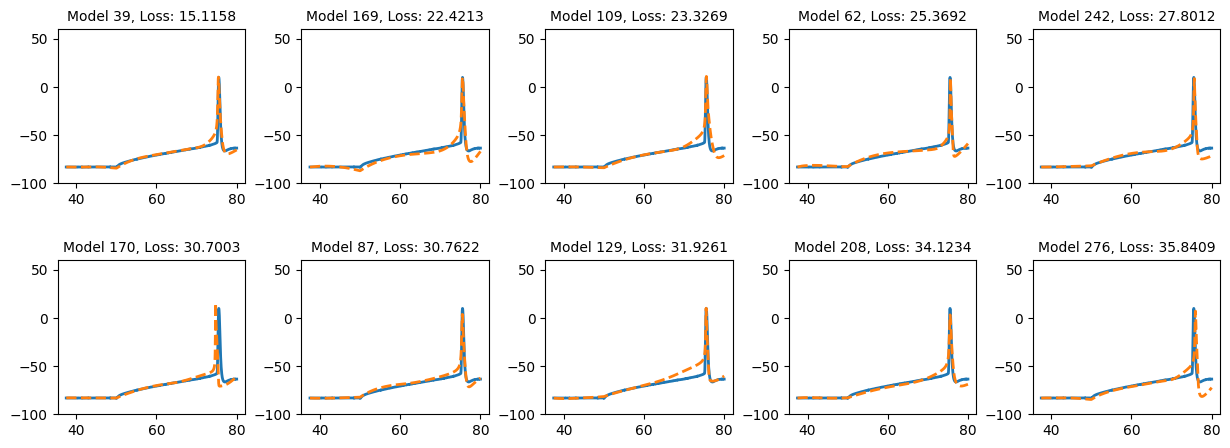

In [24]:
#t=80.0, spike_reg = 2.0
inds = np.argsort(best_losses)
best_ten_preds = []
best_ten_losses = []

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
            model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
        )
        best_ten_preds.append(final_preds)
        best_ten_losses.append(best_losses[inds[i*5+j]])
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

best_ten_preds = np.stack(best_ten_preds)
np.save("../results/losses_with_nn.npy", best_ten_losses)
np.save("../results/best_preds_with_nn.npy", best_ten_preds)

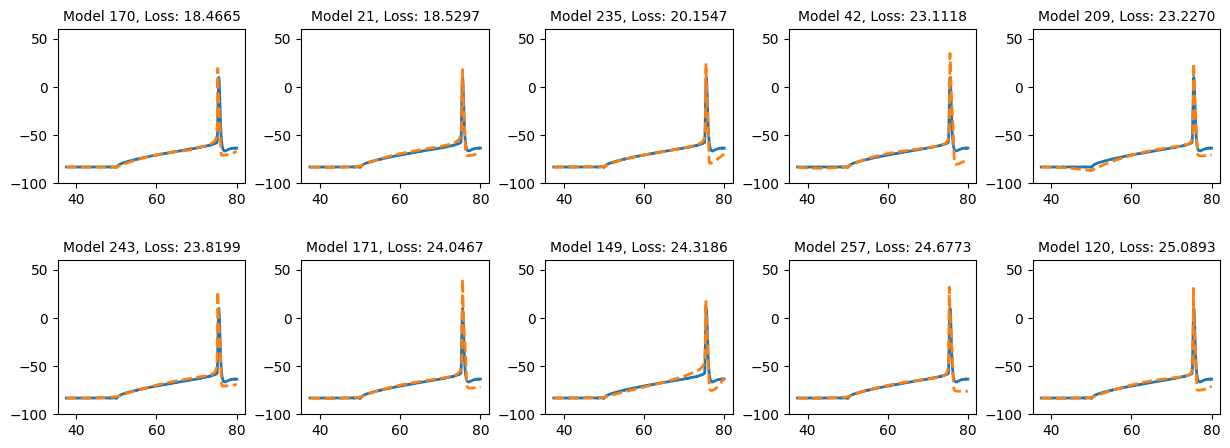

In [28]:
#t=80.0, spike_reg = 0.0
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
            model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

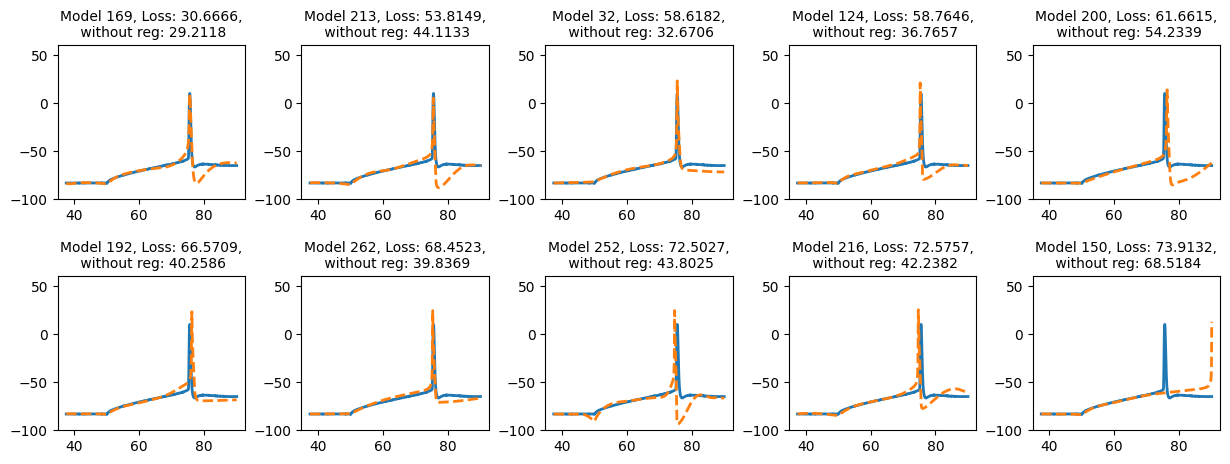

In [ ]:
#t=90.0, spike_reg = 2.0
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
            model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
        )
        loss = get_scaled_loss(v_data[0], final_preds, cost_fn_power, scale)
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f},\n without reg: {loss:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

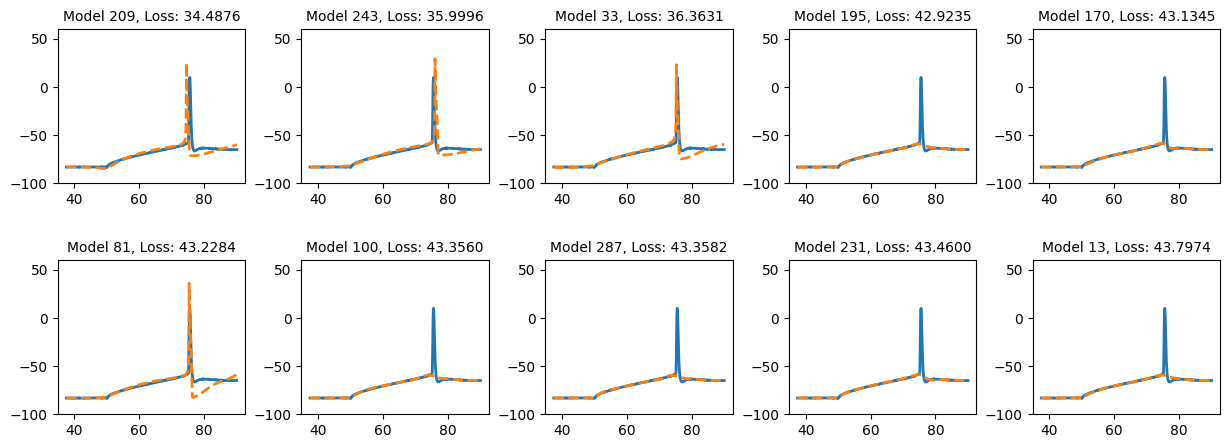

In [ ]:
#t=90.0, spike_reg = 0.0
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
            model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

In [29]:
nan_mask = jnp.isnan(grads_list[num_epochs-1].channel_params_normal)

# Get indices where the mask is True
nan_indices = jnp.argwhere(nan_mask)
print("Not successfully trained models:", int(len(nan_indices)/15))

Not successfully trained models: 1


**Checking one prediction:**

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


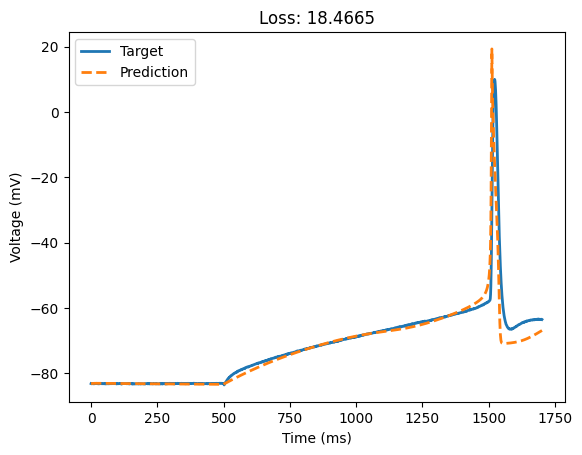

In [30]:
idx = 0
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
#cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current)
cell.record()
# cell.soma.branch(0).comp(0).stimulate(current)
# cell.soma.branch(0).comp(0).record()
cell.set("v", all_setup['v_init'])
cell.init_states()

model = jax.tree_util.tree_map(lambda x: x[inds[idx]], best_models)
opt_inv_params = inv_transform_params(model.channel_params_normal)

# Rebuild the simulator with new cell
initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

# Run simulation
final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
    model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
)

loss = simulation_loss_fn(model)


plt.plot(v_data[0], label="Data target", linewidth=2)
plt.plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.title(f"Loss: {loss:.4f}")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend(["Target", "Prediction"])


Text(0.5, 1.0, 'Dynamics network output (neural_net)')

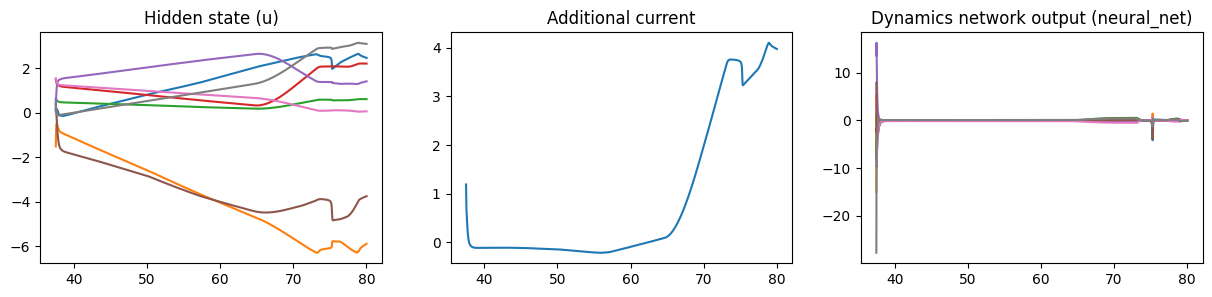

In [32]:
fig, axs = plt.subplots(1,3, figsize = (15,3))
axs[0].plot(time_vec, final_us)
axs[0].set_title("Hidden state (u)")
axs[1].plot(time_vec, final_additional_currents)
axs[1].set_title("Additional current")
axs[2].plot(time_vec, final_nn_reses)
axs[2].set_title("Dynamics network output (neural_net)")

**Fine-tuning the best 40 models with SSE loss**

In [33]:
top_k = 40
top_k_inds = inds[:top_k]
top_k_models = jax.tree_util.tree_map(lambda x: x[top_k_inds], best_models)
top_k_losses = jnp.full((top_k,), jnp.inf)

fine_tune_lr = 1e-4
decay_start = 100
decay_end = 200

fine_schedule = optax.exponential_decay(
    init_value=fine_tune_lr,
    transition_steps=1,
    decay_rate=1,
    staircase=True,
)
def fine_custom_schedule(step):
    # Epochs before decay_start → constant
    lr = fine_tune_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        fine_tune_lr,
        fine_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = fine_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr

fine_optimizer = optax.adam(fine_custom_schedule)
# fine_optimizer = optax.sgd(learning_rate=1e-8, momentum=0.9)
# fine_optimizer = optax.chain(
#             optax.scale_by_lbfgs(memory_size = 8), #8
#             optax.scale(-1e-3), #0.3
#         )

fine_optimizer_states = jax.vmap(lambda m: fine_optimizer.init(eqx.filter(m, eqx.is_inexact_array)))(top_k_models)

num_fine_epochs = 300
fine_mean_losses = []
fine_best_models = top_k_models
fine_best_losses = top_k_losses

for epoch in range(num_fine_epochs):
    # if epoch == 0: #370
    #     fine_optimizer = optax.chain(
    #         optax.scale_by_lbfgs(memory_size = 6), #8
    #         optax.scale(-0.1e-1), #0.3
    #     )
    #     fine_optimizer_states = jax.vmap(lambda m: fine_optimizer.init(eqx.filter(m, eqx.is_inexact_array)))(top_k_models)

    loss, grads = fine_grad_fn(top_k_models)

    grads = clip_channel_gradients(grads, max_norm=10.0, eps=1e-8)
    grads = scale_grads(grads, lr_main=1e-4, lr_channel=10.0)
    #grads = clip_network_gradients(grads, max_norm=10.0, eps=1e-8)

    improved = loss < fine_best_losses
    fine_best_losses = jnp.where(improved, loss, fine_best_losses)
    fine_best_models = jax.tree_util.tree_map(replace_if_improved, top_k_models, fine_best_models)

    updates, fine_optimizer_states = jax.vmap(lambda g, s, m: fine_optimizer.update(g, s, m, step=epoch))(grads, fine_optimizer_states, top_k_models)
    top_k_models = jax.vmap(eqx.apply_updates)(top_k_models, updates)

    fine_mean_losses.append(jnp.mean(loss))

    if epoch % 10 == 0:
        print(f"Fine-tune epoch {epoch}, Mean Loss: {jnp.mean(loss):.6f}, Median Loss {jnp.median(loss):.6f}, Min Loss: {jnp.min(loss):.6f}")
        print(jnp.max(jnp.linalg.norm(grads.channel_params_normal, axis=1)),
          jnp.max(jnp.linalg.norm(grads.neural_net.linear1.weight, axis=1)), jnp.max(jnp.linalg.norm(grads.neural_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.neural_net.linear2.weight, axis=1)), jnp.max(jnp.linalg.norm(grads.neural_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.neural_net.linear3.weight, axis=1)), jnp.max(jnp.linalg.norm(grads.neural_net.linear3.bias, axis=1)))


/Users/moldor/anaconda3/envs/jaxley_env/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Fine-tune epoch 0, Mean Loss: 78126.351666, Median Loss 58157.731596, Min Loss: 12983.122479
99.99999999999999 10195.102916279231 533.9033959742933 12732.622561763486 1353.0401115798684 31543.218738598527 16067.754765338803
Fine-tune epoch 10, Mean Loss: 98338.717442, Median Loss 79983.717323, Min Loss: 15316.694627
100.0 6999.035398857356 525.8098207030165 14286.660014828853 910.8464703548608 13580.983479159371 14497.13987628968
Fine-tune epoch 20, Mean Loss: 84135.023812, Median Loss 58309.880288, Min Loss: 10146.119685
99.99999999999997 4188.217712573755 399.4983383464043 8604.898677172614 656.2226539113834 7050.744695961105 11099.00918984953
Fine-tune epoch 30, Mean Loss: 78343.405950, Median Loss 55772.541595, Min Loss: 11412.601964
99.99999999999996 5376.567677450091 307.22067732728186 9997.35694806468 636.3719638636285 3991.6698393926417 8499.447763746875
Fine-tune epoch 40, Mean Loss: 73552.269780, Median Loss 56568.462067, Min Loss: 10294.741265
99.99999999999993 2434.22719784

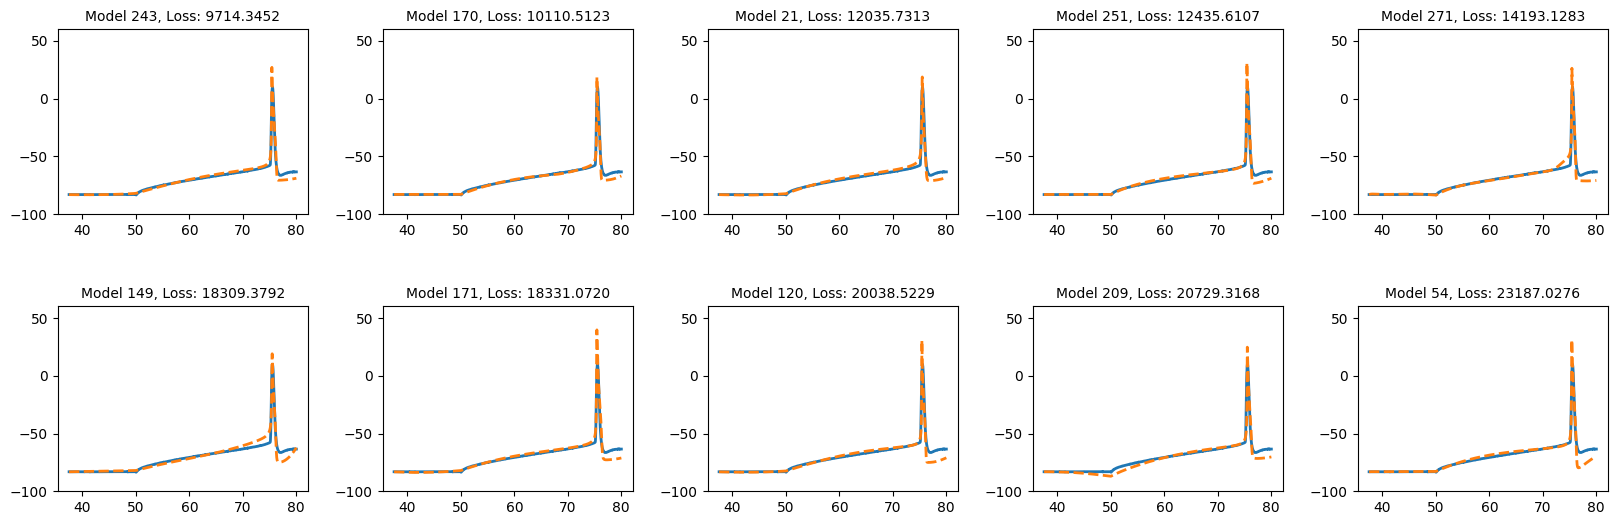

In [34]:
fine_inds = np.argsort(fine_best_losses)
fig, axs = plt.subplots(2,5, figsize = (20,6))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[fine_inds[i*5+j]], fine_best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
            model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[fine_inds[i*5+j]]}, Loss: {fine_best_losses[fine_inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


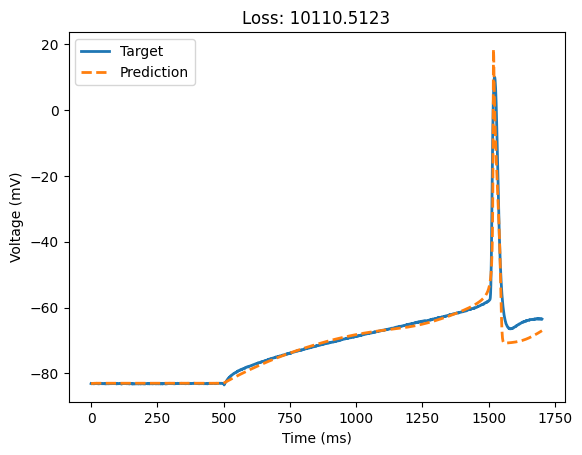

In [37]:
idx = 1

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
#cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current)
cell.record()
# cell.soma.branch(0).comp(0).stimulate(current)
# cell.soma.branch(0).comp(0).record()
cell.set("v", all_setup['v_init'])
cell.init_states()

model = jax.tree_util.tree_map(lambda x: x[fine_inds[idx]], fine_best_models)
opt_inv_params = inv_transform_params(model.channel_params_normal)

# Rebuild the simulator with new cell
initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

# Run simulation
final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
    model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
)

loss = fine_simulation_loss_fn(model)


plt.plot(v_data[0], label="Data target", linewidth=2)
plt.plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.title(f"Loss: {loss:.4f}")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend(["Target", "Prediction"])

Text(0.5, 1.0, 'Dynamics network output (neural_net)')

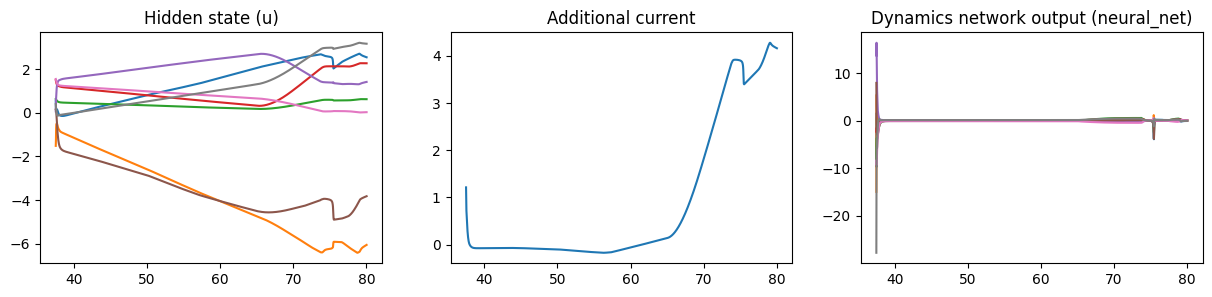

In [38]:
fig, axs = plt.subplots(1,3, figsize = (15,3))
axs[0].plot(time_vec, final_us)
axs[0].set_title("Hidden state (u)")
axs[1].plot(time_vec, final_additional_currents)
axs[1].set_title("Additional current")
axs[2].plot(time_vec, final_nn_reses)
axs[2].set_title("Dynamics network output (neural_net)")